# Cernere - Reconhecimento de Dígitos Manuscritos

Problema preditivo: Classificação de dígitos manuscritos (0-9) a partir de imagens.

Dataset: MNIST (Modified National Institute of Standards and Technology database), extraído da biblioteca `sklearn.datasets`.

In [1]:
import os
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

In [2]:
import sys
import os

sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging

from src.dataset import load_mnist_data
from src.plots import plot_digit_samples
from src.preprocessing import split_data

logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s', force=True)


## Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)

In [ ]:
# Importa o dataset MNIST via scikit-learn, fazendo uso da função definida em `src/dataset.py`. O dataset é carregado em memória e armazenado em variáveis `X` (imagens) e `y` (rótulos)
X, y = load_mnist_data()

# Verifica a dimensionalidade do dataset
print("DIMENSIONALIDADE DO DATASET:")
print(f"Formato da matriz de features (X): {X.shape}")
print(f"Formato do vetor de rótulos (y):   {y.shape}")
print(f"Tipo de dado dos pixels (X):       {X.dtype}")
print(f"Tipo de dado dos rótulos (y):      {y.dtype}")

INFO - Carregando MNIST do cache local: /Users/felipequerette/PythonProjects/mnist-digit-recognition/data/raw/mnist_784.npz
INFO - Dataset carregado com sucesso do cache local.


DIMENSIONALIDADE DO DATASET:
Formato da matriz de features (X): (70000, 784)
Formato do vetor de rótulos (y):   (70000,)
Tipo de dado dos pixels (X):       int64
Tipo de dado dos rótulos (y):      uint8


In [4]:
# Contagem e percentual de cada dígito (0 a 9)
digit_counts = pd.Series(y).value_counts().sort_index()
digit_percentages = (digit_counts / len(y)) * 100

print("DISTRIBUIÇÃO DE DÍGITOS NO DATASET:")
for digit, count, percentage in zip(digit_counts.index, digit_counts.values, digit_percentages.values):
    print(f"  Dígito {digit}: {count} ({percentage:.2f}%)")

print("-" * 30)
print(f"  Total:    {digit_counts.sum()} ({digit_percentages.sum():.2f}%)")


DISTRIBUIÇÃO DE DÍGITOS NO DATASET:
  Dígito 0: 6903 (9.86%)
  Dígito 1: 7877 (11.25%)
  Dígito 2: 6990 (9.99%)
  Dígito 3: 7141 (10.20%)
  Dígito 4: 6824 (9.75%)
  Dígito 5: 6313 (9.02%)
  Dígito 6: 6876 (9.82%)
  Dígito 7: 7293 (10.42%)
  Dígito 8: 6825 (9.75%)
  Dígito 9: 6958 (9.94%)
------------------------------
  Total:    70000 (100.00%)


INFO - Gráfico de amostras de dígitos criado com sucesso.
INFO - Imagem salva com sucesso em: /Users/felipequerette/PythonProjects/mnist-digit-recognition/outputs/images/digit_first_samples.png


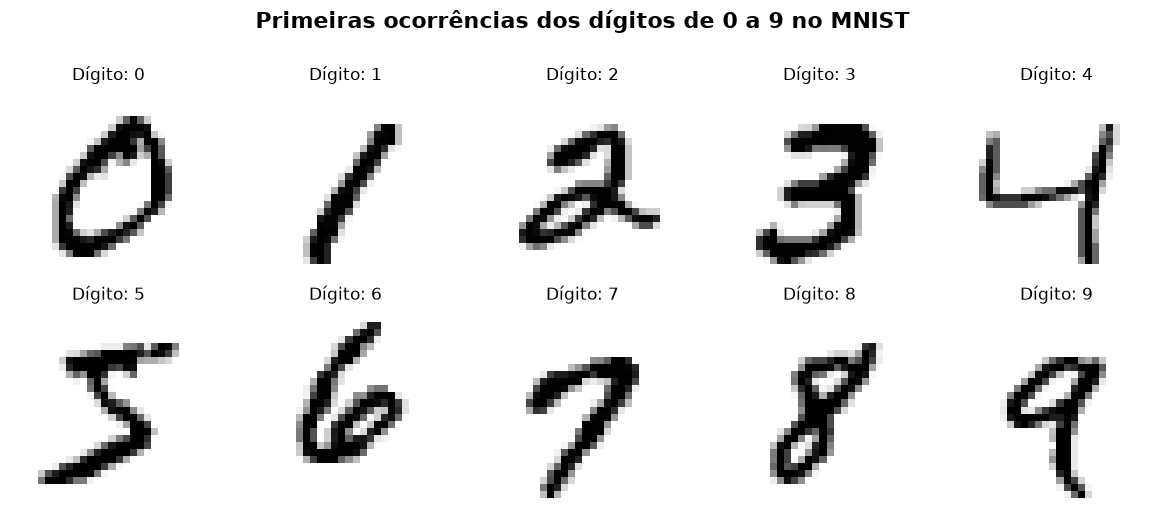

In [5]:
# Plota exemplos de imagens de cada dígito
plot_digit_samples(X, y)

### Discussão

Como vimos pela distribuição de classes, o dataset MNIST é bem equilibrado, com totais que variam entre 6.313 e 7.877 imagens por dígito.

Cada imagem é originalmente uma matriz de 28x28 pixels em escala de cinza, representando o dígito manuscrito. Cada pixel possui um valor entre 0 (preto/fundo) e 255 (branco/traço), indicando a intensidade do tom de cinza em cada ponto da imagem. Para ser utilizada na modelagem, essa matriz foi convertida em um vetor de 784 elementos (28x28), com as linhas de pixels dispostas sequencialmente. Assim, cada linha do dataset representa uma imagem de dígito manuscrito.

Embora escrevamos mais comumente com tinta escura sobre papel branco, o dataset MNIST passou por uma padronização em que os dígitos são representados com traços claros sobre fundo escuro. Isso significa que os pixels que representam o traço do dígito possuem valores mais altos (próximos de 255), enquanto os pixels do fundo possuem valores mais baixos (próximos de 0).

## Fase 2: Pré-processamento e Divisão dos Dados

In [ ]:
# Divide o dataset em conjuntos de treino, validação e teste usando a função `split_data` definida em `src/preprocessing.py`. A proporção padrão, definida em `src/config.py`, é 70% para treino, 10% para validação e 20% para teste

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)


INFO - Split realizado com sucesso:
INFO -  - Treino: 48999 amostras (70.0%)
INFO -  - Validação: 7001 amostras (10.0%)
INFO -  - Teste: 14000 amostras (20.0%)


In [ ]:
# Validação: confirma se a proporção das classes se manteve idêntica
split_check = pd.DataFrame({
    'Treino (%)': pd.Series(y_train).value_counts(normalize=True) * 100,
    'Validação (%)': pd.Series(y_val).value_counts(normalize=True) * 100,
    'Teste (%)': pd.Series(y_test).value_counts(normalize=True) * 100
}).sort_index()

display(split_check.round(2))

,Treino (%),Validação (%),Teste (%)
0,9.86,9.86,9.86
1,11.25,11.26,11.25
2,9.99,9.98,9.99
3,10.20,10.20,10.20
4,9.75,9.76,9.75
5,9.02,9.01,9.02
6,9.82,9.83,9.82
7,10.42,10.41,10.42
8,9.75,9.76,9.75
9,9.94,9.94,9.94
